In [3]:
# Cell 1: Load one processed session and run the SQI core
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_project_root(start: Path) -> Path:
    """Find the phase1 project root."""
    for candidate in (start, *start.parents):
        if (candidate / "src" / "preprocessing").is_dir():
            return candidate
        phase1_dir = candidate / "phase1"
        if (phase1_dir / "src" / "preprocessing").is_dir():
            return phase1_dir
    raise FileNotFoundError("Cannot locate the phase1 project root")


def estimate_sampling_rate(time_s: np.ndarray) -> float:
    """Estimate sampling rate from positive time intervals."""
    intervals = np.diff(time_s)
    valid = intervals[np.isfinite(intervals) & (intervals > 0)]
    if valid.size == 0:
        raise ValueError("Time axis has no positive finite interval")
    return float(1.0 / np.median(valid))


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SOURCE_DIR = PROJECT_ROOT / "src"
if str(SOURCE_DIR) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIR))

from dataloader.loader import load_session  # noqa: E402
from preprocessing.sqi import detect_motion_artifacts  # noqa: E402

SESSION_NAME = "sample_1.csv"
PROCESSED_COLUMN = "PPG processed"
WINDOW_S = 5.0
THRESHOLD = 3.5
LABEL_NAMES = {0: "Awake", 1: "Drowsy"}

data_path = (
    PROJECT_ROOT / "data_processed" / "dhdata" / SESSION_NAME
)
session_frame, metadata = load_session(data_path)
if PROCESSED_COLUMN not in session_frame.columns:
    raise ValueError(f"Missing processed PPG column: {PROCESSED_COLUMN}")

time_s = pd.to_numeric(
    session_frame["Time (s)"], errors="raise"
).to_numpy(dtype=float)
ppg_processed = pd.to_numeric(
    session_frame[PROCESSED_COLUMN], errors="raise"
).to_numpy(dtype=float)
labels = session_frame["Label"].to_numpy(copy=True)
fs = estimate_sampling_rate(time_s)
artifact_mask = detect_motion_artifacts(
    ppg_processed,
    fs,
    window_s=WINDOW_S,
    threshold=THRESHOLD,
)

if artifact_mask.shape != ppg_processed.shape:
    raise AssertionError("Artifact mask length does not match the signal")
if artifact_mask.dtype != np.bool_:
    raise AssertionError("Artifact mask must have boolean dtype")

mpl.rcParams.update({
    "axes.spines.right": False,
    "axes.spines.top": False,
    "figure.dpi": 120,
    "font.size": 9,
})
input_summary = pd.DataFrame({
    "Session": [SESSION_NAME],
    "Samples": [len(ppg_processed)],
    "Duration (s)": [time_s[-1] - time_s[0]],
    "Estimated fs (Hz)": [fs],
    "Mask dtype": [str(artifact_mask.dtype)],
    "Mask length": [len(artifact_mask)],
})
display(input_summary.style.format({
    "Duration (s)": "{:.2f}",
    "Estimated fs (Hz)": "{:.3f}",
}).hide(axis="index"))
print("SQI core completed without runtime errors.")

Session,Samples,Duration (s),Estimated fs (Hz),Mask dtype,Mask length
sample_1.csv,117828,2356.54,50.000,bool,117828


SQI core completed without runtime errors.


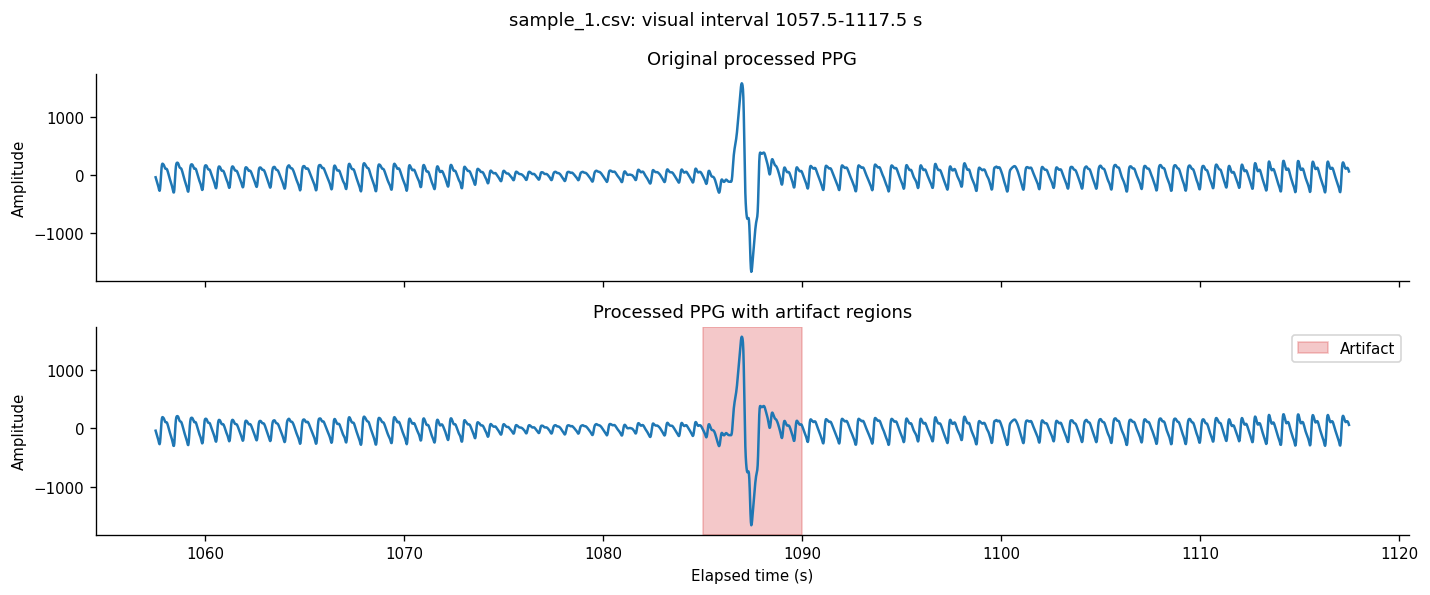

In [4]:
# Cell 2: Inspect processed PPG and highlighted artifact regions
def find_true_runs(mask: np.ndarray) -> list[tuple[int, int]]:
    """Return start and exclusive end indices of True runs."""
    padded = np.concatenate(([False], mask, [False])).astype(np.int8)
    changes = np.diff(padded)
    starts = np.flatnonzero(changes == 1)
    ends = np.flatnonzero(changes == -1)
    return list(zip(starts, ends))


elapsed_s = time_s - time_s[0]
artifact_bounds = find_true_runs(artifact_mask)
if artifact_bounds:
    first_start, first_end = artifact_bounds[0]
    event_center_s = (
        elapsed_s[first_start] + elapsed_s[first_end - 1]
    ) / 2.0
    plot_start_s = max(0.0, event_center_s - 30.0)
    plot_end_s = min(elapsed_s[-1], plot_start_s + 60.0)
    plot_start_s = max(0.0, plot_end_s - 60.0)
else:
    plot_start_s = 0.0
    plot_end_s = min(60.0, elapsed_s[-1])

plot_mask = (elapsed_s >= plot_start_s) & (elapsed_s <= plot_end_s)
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(elapsed_s[plot_mask], ppg_processed[plot_mask])
axes[0].set_title("Original processed PPG")
axes[1].plot(elapsed_s[plot_mask], ppg_processed[plot_mask])
highlight_label_added = False
for start, end in artifact_bounds:
    event_start_s = elapsed_s[start]
    event_end_s = elapsed_s[end - 1] + 1.0 / fs
    if event_end_s < plot_start_s or event_start_s > plot_end_s:
        continue
    label = "Artifact" if not highlight_label_added else None
    axes[1].axvspan(
        event_start_s,
        event_end_s,
        color="tab:red",
        alpha=0.25,
        label=label,
    )
    highlight_label_added = True
axes[1].set_title("Processed PPG with artifact regions")
for axis in axes:
    axis.set_ylabel("Amplitude")
axes[1].set_xlabel("Elapsed time (s)")
if highlight_label_added:
    axes[1].legend(loc="upper right")
fig.suptitle(
    f"{SESSION_NAME}: visual interval {plot_start_s:.1f}-{plot_end_s:.1f} s"
)
fig.tight_layout()
plt.show()

In [5]:
# Cell 3: Aggregate flagged samples into artifact events
def format_label(values: np.ndarray) -> str:
    """Return the most frequent label name."""
    modes = pd.Series(values).mode(dropna=True)
    if modes.empty:
        return "Unknown"
    value = modes.iloc[0]
    return LABEL_NAMES.get(value, str(value))


artifact_rows = []
for artifact_number, (start, end) in enumerate(artifact_bounds, start=1):
    start_s = elapsed_s[start]
    end_s = elapsed_s[end - 1] + 1.0 / fs
    artifact_rows.append({
        "Artifact": artifact_number,
        "Start (s)": start_s,
        "End (s)": end_s,
        "Duration (s)": end_s - start_s,
        "Label": format_label(labels[start:end]),
    })

artifact_events = pd.DataFrame(artifact_rows, columns=[
    "Artifact",
    "Start (s)",
    "End (s)",
    "Duration (s)",
    "Label",
])
display(artifact_events.style.format({
    "Start (s)": "{:.2f}",
    "End (s)": "{:.2f}",
    "Duration (s)": "{:.2f}",
}).hide(axis="index"))

total_artifact_s = float(artifact_mask.sum() / fs)
artifact_percentage = float(100.0 * artifact_mask.mean())
artifact_summary = pd.DataFrame({
    "Metric": [
        "Artifacts",
        "Total artifact time (s)",
        "Artifact time (%)",
        "Artifacts in Awake",
        "Artifacts in Drowsy",
    ],
    "Value": [
        len(artifact_events),
        total_artifact_s,
        artifact_percentage,
        int((artifact_events["Label"] == "Awake").sum()),
        int((artifact_events["Label"] == "Drowsy").sum()),
    ],
})
display(artifact_summary.style.format({"Value": "{:.2f}"})
        .hide(axis="index"))

Artifact,Start (s),End (s),Duration (s),Label
1,1085.00,1090.00,5.00,Drowsy
2,2350.00,2356.56,6.56,Drowsy


Metric,Value
Artifacts,2.00
Total artifact time (s),11.56
Artifact time (%),0.49
Artifacts in Awake,0.00
Artifacts in Drowsy,2.00


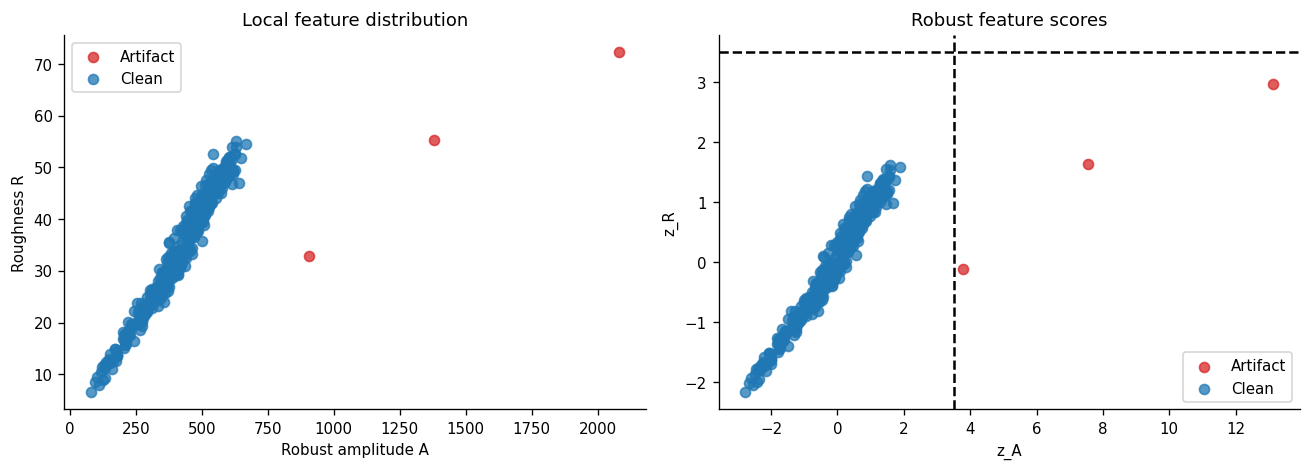

In [6]:
# Cell 4: Reproduce local SQI features for diagnosis
def calculate_window_features(
    signal: np.ndarray,
    fs: float,
    window_s: float,
    threshold: float,
) -> pd.DataFrame:
    """Calculate the window features used by the SQI core."""
    window_samples = max(2, int(round(window_s * fs)))
    rows = []
    for start in range(0, len(signal), window_samples):
        end = min(start + window_samples, len(signal))
        segment = signal[start:end]
        if len(segment) < 2:
            continue
        amplitude = (
            np.quantile(segment, 0.95) - np.quantile(segment, 0.05)
        )
        rows.append({
            "Start index": start,
            "End index": end,
            "A": amplitude,
            "R": np.sqrt(np.mean(np.diff(segment) ** 2)),
        })
    features = pd.DataFrame(rows)
    for feature_name in ("A", "R"):
        values = features[feature_name]
        median = values.median()
        mad = np.median(np.abs(values - median))
        mad = max(float(mad), np.finfo(float).eps)
        features[f"z_{feature_name}"] = (
            0.6745 * (values - median) / mad
        )
    features["Artifact"] = (features["z_A"] > threshold) | (
        features["z_R"] > threshold
    )
    features["State"] = np.where(
        features["Artifact"], "Artifact", "Clean"
    )
    return features


window_features = calculate_window_features(
    ppg_processed, fs, WINDOW_S, THRESHOLD
)
window_features["Start (s)"] = elapsed_s[
    window_features["Start index"].to_numpy(dtype=int)
]
end_indices = window_features["End index"].to_numpy(dtype=int) - 1
window_features["End (s)"] = elapsed_s[end_indices] + 1.0 / fs
reconstructed_mask = np.zeros(len(ppg_processed), dtype=bool)
for row in window_features.itertuples(index=False):
    if row.Artifact:
        reconstructed_mask[row[0]:row[1]] = True
if not np.array_equal(reconstructed_mask, artifact_mask):
    raise AssertionError("Feature flags do not reproduce the core mask")

display_columns = [
    "Start (s)",
    "End (s)",
    "A",
    "R",
    "z_A",
    "z_R",
    "State",
]
# display(window_features[display_columns].style.format({
#     "Start (s)": "{:.2f}",
#     "End (s)": "{:.2f}",
#     "A": "{:.3f}",
#     "R": "{:.3f}",
#     "z_A": "{:.2f}",
#     "z_R": "{:.2f}",
# }).hide(axis="index"))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = {"Clean": "tab:blue", "Artifact": "tab:red"}
for state, group in window_features.groupby("State"):
    axes[0].scatter(
        group["A"],
        group["R"],
        color=colors[state],
        label=state,
        alpha=0.75,
    )
    axes[1].scatter(
        group["z_A"],
        group["z_R"],
        color=colors[state],
        label=state,
        alpha=0.75,
    )
axes[0].set_title("Local feature distribution")
axes[0].set_xlabel("Robust amplitude A")
axes[0].set_ylabel("Roughness R")
axes[1].axvline(THRESHOLD, color="black", linestyle="--")
axes[1].axhline(THRESHOLD, color="black", linestyle="--")
axes[1].set_title("Robust feature scores")
axes[1].set_xlabel("z_A")
axes[1].set_ylabel("z_R")
for axis in axes:
    axis.legend()
fig.tight_layout()
plt.show()

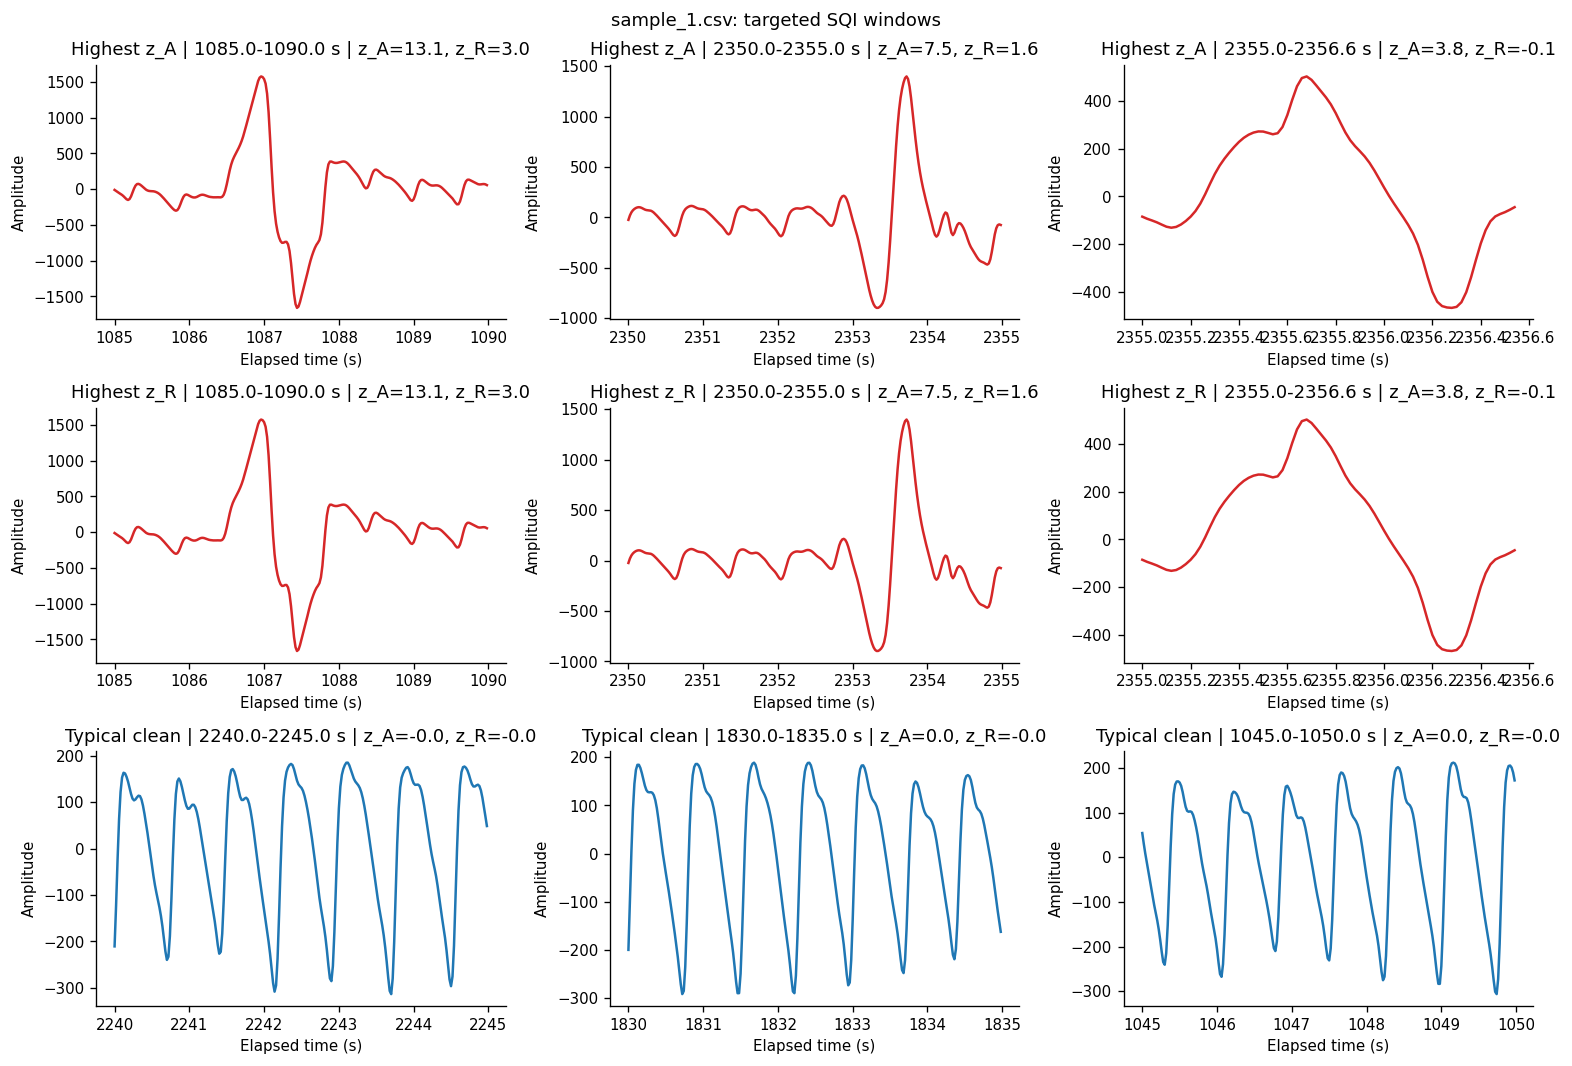

In [7]:
# Cell 5: Inspect extreme artifact and typical clean windows
artifact_feature_rows = window_features[window_features["Artifact"]]
clean_feature_rows = window_features[~window_features["Artifact"]].copy()
clean_feature_rows["Distance"] = np.hypot(
    clean_feature_rows["z_A"], clean_feature_rows["z_R"]
)
target_groups = [
    ("Highest z_A", artifact_feature_rows.nlargest(3, "z_A")),
    ("Highest z_R", artifact_feature_rows.nlargest(3, "z_R")),
    ("Typical clean", clean_feature_rows.nsmallest(3, "Distance")),
]
target_rows = []
for role, group in target_groups:
    for _, row in group.iterrows():
        target_rows.append((role, row))

column_count = 3
row_count = int(np.ceil(len(target_rows) / column_count))
fig, axes = plt.subplots(
    row_count,
    column_count,
    figsize=(13, 3 * row_count),
    squeeze=False,
)
for axis, (role, row) in zip(axes.flat, target_rows):
    start = int(row["Start index"])
    end = int(row["End index"])
    color = "tab:red" if row["Artifact"] else "tab:blue"
    axis.plot(elapsed_s[start:end], ppg_processed[start:end], color=color)
    axis.set_title(
        f"{role} | {row['Start (s)']:.1f}-{row['End (s)']:.1f} s | "
        f"z_A={row['z_A']:.1f}, z_R={row['z_R']:.1f}"
    )
    axis.set_xlabel("Elapsed time (s)")
    axis.set_ylabel("Amplitude")
for axis in axes.flat[len(target_rows):]:
    axis.set_visible(False)
fig.suptitle(f"{SESSION_NAME}: targeted SQI windows")
fig.tight_layout()
plt.show()

Region,Flagged samples (%),Passed
Clean,0.0,True
Amplitude artifact,100.0,True
Roughness artifact,100.0,True


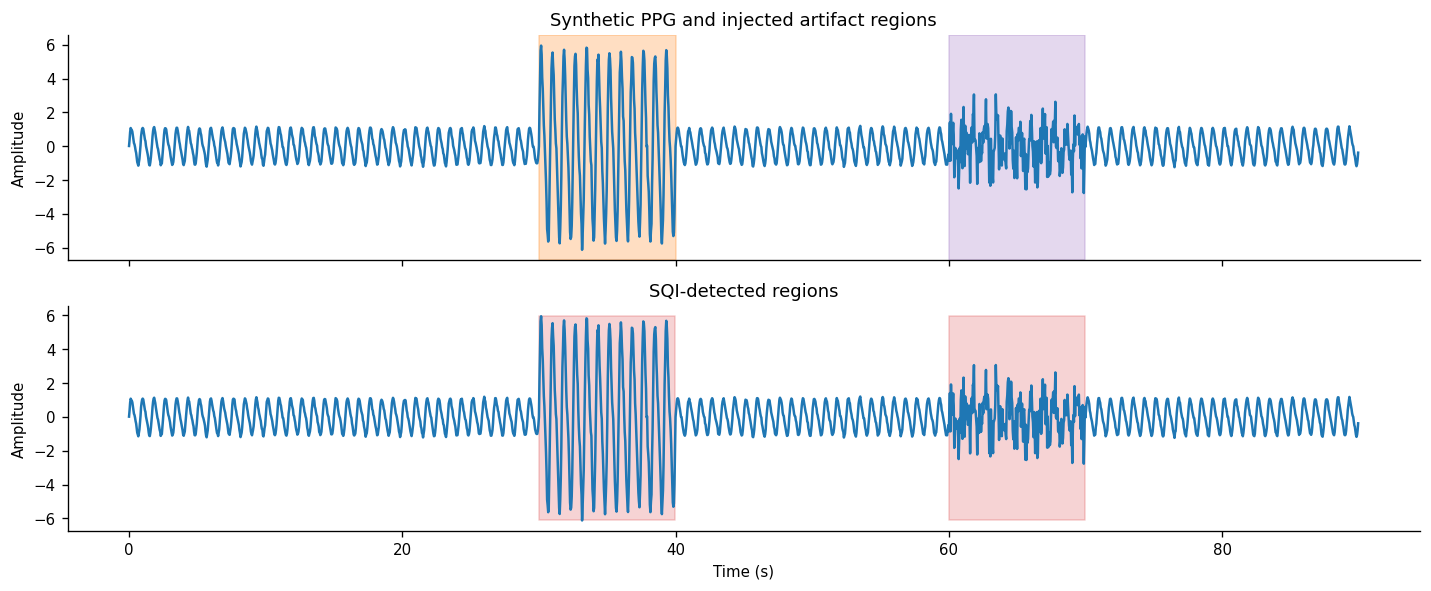

All synthetic SQI checks passed.


In [8]:
# Cell 6: Run a synthetic SQI sanity test
SYNTHETIC_FS = 25.0
synthetic_time_s = np.arange(0.0, 90.0, 1.0 / SYNTHETIC_FS)
random_generator = np.random.default_rng(42)
synthetic_ppg = (
    np.sin(2 * np.pi * 1.2 * synthetic_time_s)
    + 0.25 * np.sin(2 * np.pi * 2.4 * synthetic_time_s)
    + 0.05 * random_generator.standard_normal(len(synthetic_time_s))
)
amplitude_region = (synthetic_time_s >= 30.0) & (synthetic_time_s < 40.0)
roughness_region = (synthetic_time_s >= 60.0) & (synthetic_time_s < 70.0)
clean_region = ~(amplitude_region | roughness_region)
synthetic_ppg[amplitude_region] *= 5.0
synthetic_ppg[roughness_region] += (
    0.8 * random_generator.standard_normal(roughness_region.sum())
)
synthetic_mask = detect_motion_artifacts(
    synthetic_ppg,
    SYNTHETIC_FS,
    window_s=WINDOW_S,
    threshold=THRESHOLD,
)
synthetic_checks = pd.DataFrame({
    "Region": ["Clean", "Amplitude artifact", "Roughness artifact"],
    "Flagged samples (%)": [
        100.0 * synthetic_mask[clean_region].mean(),
        100.0 * synthetic_mask[amplitude_region].mean(),
        100.0 * synthetic_mask[roughness_region].mean(),
    ],
})
synthetic_checks["Passed"] = [
    not synthetic_mask[clean_region].any(),
    synthetic_mask[amplitude_region].any(),
    synthetic_mask[roughness_region].any(),
]
display(synthetic_checks.style.format({
    "Flagged samples (%)": "{:.1f}",
}).hide(axis="index"))
if not synthetic_checks["Passed"].all():
    raise AssertionError("One or more synthetic SQI checks failed")

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(synthetic_time_s, synthetic_ppg)
axes[0].axvspan(30.0, 40.0, color="tab:orange", alpha=0.25)
axes[0].axvspan(60.0, 70.0, color="tab:purple", alpha=0.25)
axes[0].set_title("Synthetic PPG and injected artifact regions")
axes[1].plot(synthetic_time_s, synthetic_ppg)
axes[1].fill_between(
    synthetic_time_s,
    synthetic_ppg.min(),
    synthetic_ppg.max(),
    where=synthetic_mask,
    color="tab:red",
    alpha=0.2,
)
axes[1].set_title("SQI-detected regions")
for axis in axes:
    axis.set_ylabel("Amplitude")
axes[1].set_xlabel("Time (s)")
fig.tight_layout()
plt.show()
print("All synthetic SQI checks passed.")

Window (s),Threshold,Artifacts,Artifact duration (%),Artifact intervals (s)
3,3.0,2,0.321,"1086.0-1089.0, 2352.0-2356.6"
3,3.5,2,0.321,"1086.0-1089.0, 2352.0-2356.6"
3,4.0,2,0.255,"1086.0-1089.0, 2352.0-2355.0"
5,3.0,2,0.491,"1085.0-1090.0, 2350.0-2356.6"
5,3.5,2,0.491,"1085.0-1090.0, 2350.0-2356.6"
5,4.0,2,0.424,"1085.0-1090.0, 2350.0-2355.0"
10,3.0,2,0.703,"1080.0-1090.0, 2350.0-2356.6"
10,3.5,2,0.703,"1080.0-1090.0, 2350.0-2356.6"
10,4.0,2,0.703,"1080.0-1090.0, 2350.0-2356.6"


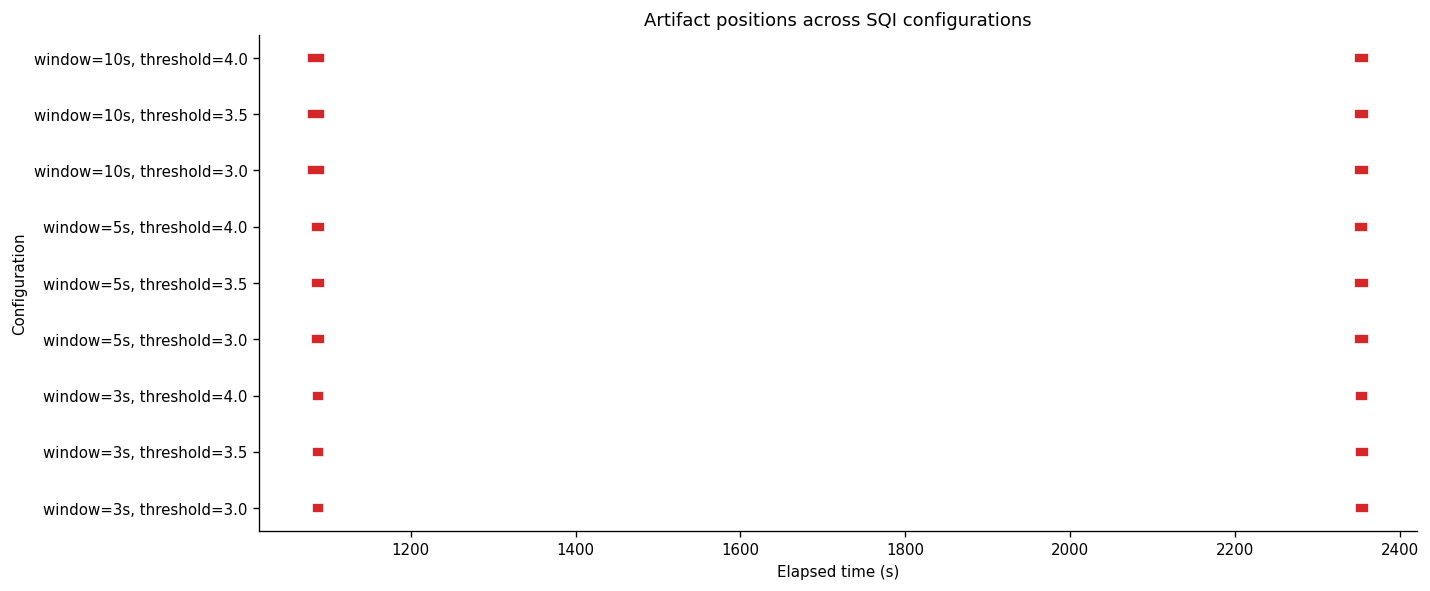

In [9]:
# Cell 7: Compare nearby SQI parameter configurations
WINDOW_OPTIONS_S = [3.0, 5.0, 10.0]
THRESHOLD_OPTIONS = [3.0, 3.5, 4.0]
sensitivity_rows = []
sensitivity_positions = {}
for window_s in WINDOW_OPTIONS_S:
    for threshold in THRESHOLD_OPTIONS:
        test_mask = detect_motion_artifacts(
            ppg_processed,
            fs,
            window_s=window_s,
            threshold=threshold,
        )
        event_bounds = find_true_runs(test_mask)
        configuration = f"window={window_s:g}s, threshold={threshold:.1f}"
        event_intervals = [
            (elapsed_s[start], elapsed_s[end - 1] + 1.0 / fs)
            for start, end in event_bounds
        ]
        sensitivity_positions[configuration] = event_intervals
        position_text = ", ".join(
            f"{start_s:.1f}-{end_s:.1f}"
            for start_s, end_s in event_intervals
        )
        sensitivity_rows.append({
            "Window (s)": window_s,
            "Threshold": threshold,
            "Artifacts": len(event_bounds),
            "Artifact duration (%)": 100.0 * test_mask.mean(),
            "Artifact intervals (s)": position_text or "None",
        })

parameter_sensitivity = pd.DataFrame(sensitivity_rows)
display(parameter_sensitivity.style.format({
    "Window (s)": "{:.0f}",
    "Threshold": "{:.1f}",
    "Artifact duration (%)": "{:.3f}",
}).hide(axis="index"))

fig, axis = plt.subplots(figsize=(12, 5))
configuration_names = list(sensitivity_positions)
for row_index, configuration in enumerate(configuration_names):
    for start_s, end_s in sensitivity_positions[configuration]:
        axis.plot(
            [start_s, end_s],
            [row_index, row_index],
            color="tab:red",
            linewidth=5,
        )
axis.set_yticks(range(len(configuration_names)))
axis.set_yticklabels(configuration_names)
axis.set_xlabel("Elapsed time (s)")
axis.set_ylabel("Configuration")
axis.set_title("Artifact positions across SQI configurations")
fig.tight_layout()
plt.show()

## Tổng hợp kết quả SQI core validation

### Session và output mask

- Session được sử dụng là `sample_1.csv` trong `data_processed/dhdata`.
- Tín hiệu đầu vào lấy từ cột `PPG processed`, gồm **117.828 mẫu** và có thời lượng **2.356,54 giây**.
- Sampling rate ước lượng từ `Time (s)` là **50,000 Hz**.
- `detect_motion_artifacts()` chạy với `window_s = 5,0` và `threshold = 3,5`.
- Output mask có **117.828 phần tử**, cùng chiều dài với tín hiệu, và có kiểu dữ liệu boolean.
- Quá trình chạy core không phát sinh runtime error.

### Artifact events

Ba window bị flag liên tiếp theo từng vùng được gộp thành **2 artifact event**:

| Artifact | Start (s) | End (s) | Duration (s) | Label |
| ---: | ---: | ---: | ---: | --- |
| 1 | 1.085,00 | 1.090,00 | 5,00 | Drowsy |
| 2 | 2.350,00 | 2.356,56 | 6,56 | Drowsy |

- Tổng thời gian được đánh dấu artifact là **11,56 giây**, tương ứng **0,49%** số mẫu của session.
- Số artifact thuộc `Awake` là **0**; số artifact thuộc `Drowsy` là **2**.
- Cell visual inspection đã vẽ cùng một đoạn PPG processed trước và sau khi bổ sung vùng highlight cho artifact đầu tiên.

### Feature diagnostic

Feature `A`, `R`, `z_A` và `z_R` được lưu cho toàn bộ local window. Ba window có trạng thái artifact là:

| Interval (s) | A | R | z_A | z_R |
| --- | ---: | ---: | ---: | ---: |
| 1.085,00--1.090,00 | 2.081,238 | 72,230 | 13,13 | 2,97 |
| 2.350,00--2.355,00 | 1.378,826 | 55,303 | 7,54 | 1,65 |
| 2.355,00--2.356,56 | 906,437 | 32,805 | 3,79 | -0,11 |

Mask được tái tạo từ các feature window trùng khớp với mask trả về bởi core. Notebook đã tạo scatter của `A` theo `R`, scatter của `z_A` theo `z_R`, và đánh dấu các window artifact. Cell targeted inspection cũng đã vẽ top 3 window theo `z_A`, top 3 theo `z_R` và 3 clean window gần tâm robust-score nhất.

### Synthetic sanity test

| Region | Flagged samples (%) | Check |
| --- | ---: | --- |
| Clean | 0,0 | Passed |
| Amplitude artifact | 100,0 | Passed |
| Roughness artifact | 100,0 | Passed |

Synthetic signal dài 90 giây gồm vùng clean, vùng tăng amplitude tại 30--40 giây và vùng rapid fluctuation tại 60--70 giây. Notebook đã vẽ cả vùng artifact được chèn và vùng mask do SQI phát hiện.

### Parameter sensitivity

| Window (s) | Threshold | Artifacts | Artifact duration (%) | Artifact intervals (s) |
| ---: | ---: | ---: | ---: | --- |
| 3 | 3,0 | 2 | 0,321 | 1.086,0--1.089,0; 2.352,0--2.356,6 |
| 3 | 3,5 | 2 | 0,321 | 1.086,0--1.089,0; 2.352,0--2.356,6 |
| 3 | 4,0 | 2 | 0,255 | 1.086,0--1.089,0; 2.352,0--2.355,0 |
| 5 | 3,0 | 2 | 0,491 | 1.085,0--1.090,0; 2.350,0--2.356,6 |
| 5 | 3,5 | 2 | 0,491 | 1.085,0--1.090,0; 2.350,0--2.356,6 |
| 5 | 4,0 | 2 | 0,424 | 1.085,0--1.090,0; 2.350,0--2.355,0 |
| 10 | 3,0 | 2 | 0,703 | 1.080,0--1.090,0; 2.350,0--2.356,6 |
| 10 | 3,5 | 2 | 0,703 | 1.080,0--1.090,0; 2.350,0--2.356,6 |
| 10 | 4,0 | 2 | 0,703 | 1.080,0--1.090,0; 2.350,0--2.356,6 |

Cả 9 cấu hình đều tạo **2 artifact event**. Artifact duration nằm trong khoảng **0,255--0,703%**; các event tập trung quanh hai vùng thời gian 1.080--1.090 giây và 2.350 giây đến cuối session. Timeline trong cell cuối hiển thị vị trí event của từng cấu hình.